# Resolving the G1-S artifact

Adding a +1 offset to the genome deconvolution handles the initial issue of small counts near zero creating a spike in the smoothing transition from G1 to S/G2M. There still appears to be an elevated occupancy in G1 across the entire genome that isn't fully understood.



In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1689]:
chrom = 16
span = 771000, 771600


In [1690]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)


Adding a deconvolution offset to G: 1


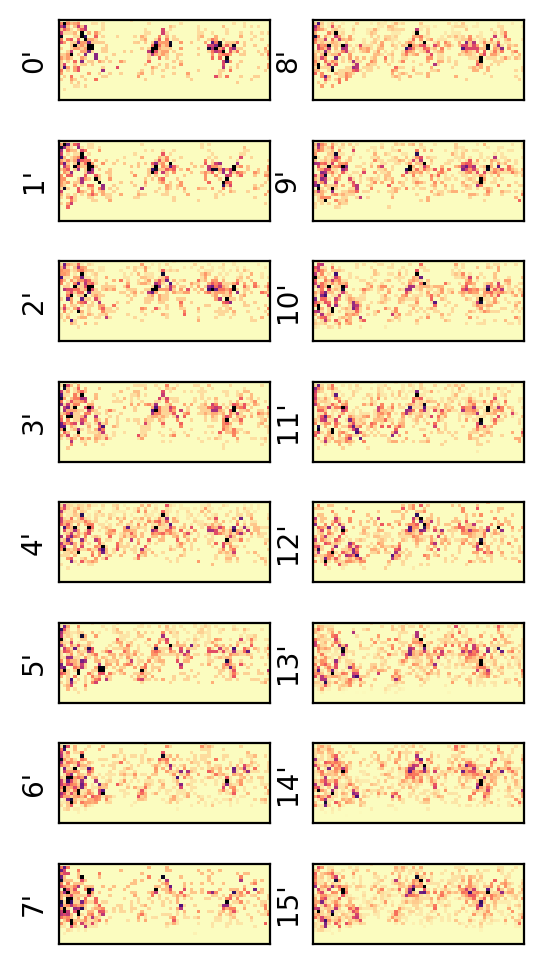

In [1726]:
from src.mnase_total_curve_debugging import plot_G_img_data

G1_img_data = genome_deconvolution.combined_model.chrom1_model.deconv_hist_unflattened
plot_G_img_data(G1_img_data)

In [1749]:
genome_deconvolution.combined_model.deconvolve(gamma=0.06, padding_type='left')

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.06
Deconvolving bin size: 10x10
of G shape: (31, 1560)
Deconvolving with gamma=0.06
0/1560 - 00:00:00.314
500/1560 - 00:02:22.990
1000/1560 - 00:04:44.025
1500/1560 - 00:07:08.056
Deconvolved in : 00:07:25.396
The fitting norm is 1.50, the smoothing norm is: 4.19


In [ ]:
from src.mnase_total_curve_debugging import plot_f_genome_deconvolution_nuc_reads

plot_f_genome_deconvolution_nuc_reads(genome_deconvolution)

In [ ]:

img_shape = genome_deconvolution.combined_model\
    .chrom1_model.deconv_hist_unflattened.shape[1:]

f_imgs = genome_deconvolution.combined_model.deconvolved_f_value.reshape(
    (-1, *img_shape))
f_imgs.shape

index = 0
fig, axs = plt.subplots(4, 5, figsize=(9, 3))
axs = np.array(axs).T.flatten()

for i in range(0, 178, 10):
    ax = axs[index]
    f_img = f_imgs[i]
    normalized_f_img = f_img / f_img.sum() * 2000
    ax.imshow(normalized_f_img, origin='lower', vmin=1, vmax=5, 
               aspect='auto', cmap='magma_r')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axvline(28, lw=1)
    index += 1


In [ ]:
# Let's summarize:
# 1. Normalize the total read counts on analysis
# 2. Padding both sides creates an interesting curve, the initial to postG
#